In [1]:
import urllib.request
import json
import pandas as pd
import seaborn
import numpy as np

In [2]:
# https://community.cratedb.com/t/advanced-downsampling-with-the-lttb-algorithm/1287

txt = urllib.request.urlopen(
    "https://raw.githubusercontent.com/sveinn-steinarsson/flot-downsample/8bb3db00f035dfab897e29d01fd7ae1d9dc999b2/demo_data.js"
).read()
txt = txt[15 : (len(txt) - 1)]
txt = txt.decode("utf-8")
data = json.loads(txt)
odf = pd.DataFrame(data[1])

# repeat the data to simply increase the dataset size. The execution time differences
# between the UDF lttb implementation and the native lttb implementation are more visible with larger data
df = pd.concat([odf] * 200 , ignore_index=True)

# Update 'n' so it is a continuous sequence and not just a repeat of "n" in the dataset
df['n'] = np.arange(len(df))
df=df.drop(columns=[0])
df.columns = [ "reading","n"]

# crate needs to be running locally
df.to_sql("demo", "crate://localhost:4200", if_exists="replace", index=False)

-1

<Axes: xlabel='n', ylabel='reading'>

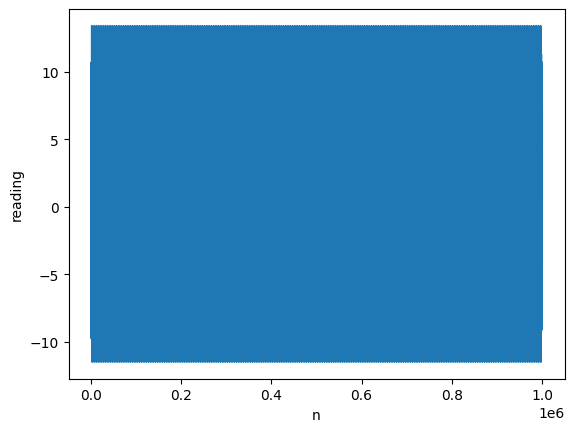

In [3]:
seaborn.lineplot(df, x="n", y="reading")

In [4]:
%%time
pd.read_sql("SELECT count(*) from demo", "crate://localhost:4200")

CPU times: user 6.4 ms, sys: 1.95 ms, total: 8.35 ms
Wall time: 616 ms


,count
0,1000000


CPU times: user 69.1 ms, sys: 1.91 ms, total: 71 ms
Wall time: 340 ms


<Axes: xlabel='bucket', ylabel='reading'>

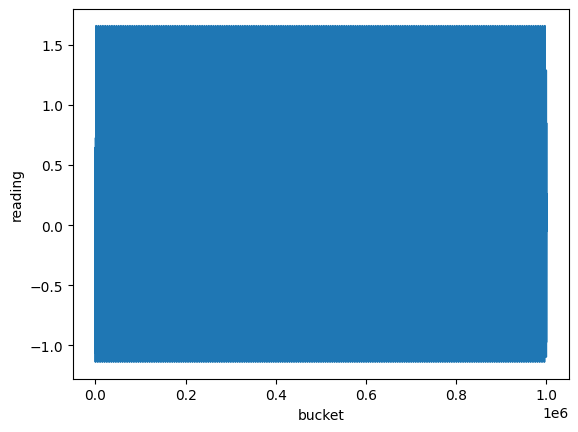

In [5]:
%%time
avg_query = """
	SELECT (n / 50) * 50 AS bucket,
           avg(reading) AS reading
	FROM demo 
	GROUP BY bucket
"""
dfavg_data = pd.read_sql(avg_query, "crate://localhost:4200")
seaborn.lineplot(dfavg_data, x="bucket", y="reading")

In [6]:
create_udf = """CREATE OR REPLACE FUNCTION lttb_with_parallel_arrays (xarray ARRAY(INTEGER),yarray ARRAY(FLOAT), threshold int)
RETURNS OBJECT(IGNORED)
LANGUAGE JAVASCRIPT
AS
'    
    function lttb_with_parallel_arrays(xarray,yarray,threshold) {

        var data_length = xarray.length;
        if (threshold >= data_length || threshold === 0) {
            return Object.assign({}, [xarray,yarray]); // Nothing to do
        }

        var sampledx = [],
			sampledy = [],
            sampled_index = 0;

        // Bucket size. Leave room for start and end data points
        var every = (data_length - 2) / (threshold - 2);

        var a = 0,  // Initially a is the first point in the triangle
            max_area_point,
            max_area,
            area,
            next_a;

        sampledx[ sampled_index ] = xarray[a];
		sampledy[ sampled_index++ ] = yarray[a]; // Always add the first point

        for (var i = 0; i < threshold - 2; i++) {

            // Calculate point average for next bucket (containing c)
            var avg_x = 0,
                avg_y = 0,
                avg_range_start  = Math.floor( ( i + 1 ) * every ) + 1,
                avg_range_end    = Math.floor( ( i + 2 ) * every ) + 1;
            avg_range_end = avg_range_end < data_length ? avg_range_end : data_length;

            var avg_range_length = avg_range_end - avg_range_start;

            for ( ; avg_range_start<avg_range_end; avg_range_start++ ) {
              avg_x += xarray[ avg_range_start ] * 1; // * 1 enforces Number (value may be Date)
              avg_y += yarray[ avg_range_start ] * 1;
            }
            avg_x /= avg_range_length;
            avg_y /= avg_range_length;

            // Get the range for this bucket
            var range_offs = Math.floor( (i + 0) * every ) + 1,
                range_to   = Math.floor( (i + 1) * every ) + 1;

            // Point a
            var point_a_x = xarray[ a ] * 1, // enforce Number (value may be Date)
                point_a_y = yarray[ a ] * 1;

            max_area = area = -1;

            for ( ; range_offs < range_to; range_offs++ ) {
                // Calculate triangle area over three buckets
                area = Math.abs( ( point_a_x - avg_x ) * ( yarray[ range_offs ] - point_a_y ) -
                            ( point_a_x - xarray[ range_offs ] ) * ( avg_y - point_a_y )
                          ) * 0.5;
                if ( area > max_area ) {
                    max_area = area;
                    max_area_point = [xarray[range_offs],yarray[range_offs]];
                    next_a = range_offs; // Next a is this b
                }
            }

            sampledx[ sampled_index ] = max_area_point[0];
			sampledy[ sampled_index++ ] = max_area_point[1]; // Pick this point from the bucket
            a = next_a; // This a is the next a (chosen b)
        }

        sampledx[ sampled_index ] = xarray[data_length - 1];
		sampledy[ sampled_index++ ] = yarray[data_length - 1]; // Always add last				
		
        return Object.assign({}, [sampledx,sampledy]);
    }

';"""
pd.read_sql(create_udf, "crate://localhost:4200")

""


In [7]:
routines_query = """SELECT routine_schema, specific_name
FROM information_schema.routines 
WHERE routine_name = 'lttb_with_parallel_arrays'
"""
pd.read_sql(routines_query, "crate://localhost:4200")

,routine_schema,specific_name
0,doc,"lttb_with_parallel_arrays(integer_array, real_..."


CPU times: user 40.9 ms, sys: 2.08 ms, total: 42.9 ms
Wall time: 2.47 s


<Axes: xlabel='n', ylabel='reading'>

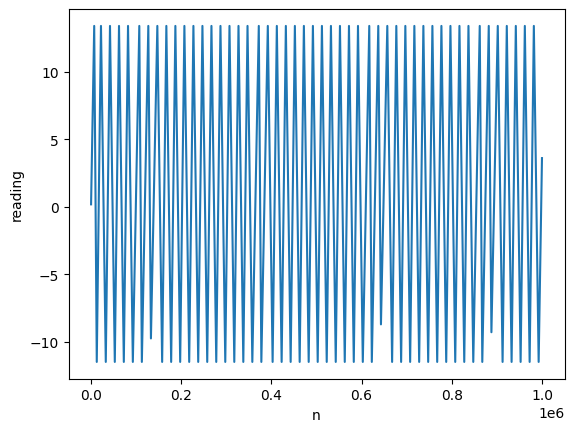

In [8]:
%%time
lttb_udf_query = """
    WITH downsampleddata AS (
        SELECT lttb_with_parallel_arrays(	
                   array(SELECT n FROM demo ORDER BY n),							
                   array(SELECT reading FROM demo ORDER BY n),
                    100
               ) AS lttb
    )
	SELECT unnest(lttb['0']) as n, unnest(lttb['1']) AS reading
	FROM downsampleddata;
"""
dflttb_data = pd.read_sql(lttb_udf_query, "crate://localhost:4200")
seaborn.lineplot(dflttb_data, x="n", y="reading")

CPU times: user 50.1 ms, sys: 2.91 ms, total: 53 ms
Wall time: 426 ms


<Axes: xlabel='n', ylabel='reading'>

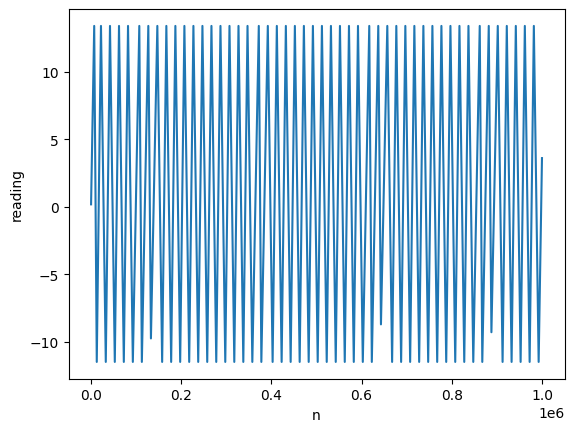

In [9]:
%%time
lttb_native = """
WITH downsampled AS (
SELECT lttb(n, reading, 100) AS lttb_data
FROM demo) 
select unnest((lttb_data).x) AS n, unnest((lttb_data).y) as reading
FROM downsampled; 
"""
dflttb_data = pd.read_sql(lttb_native, "crate://localhost:4200")
seaborn.lineplot(dflttb_data, x="n", y="reading")